<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/03_salmonellosis_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Forecasting

## Imports

In [88]:
%pip install -q pmdarima

In [89]:
# imports
import os
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
import statsmodels.tsa.api as tsa
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from pmdarima.arima import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split
import pmdarima as pm

## Custom Functions

In [91]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [92]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [93]:
### NEW FUNCTION FOR COMBINED ACF/PACF WITH ANNOTATIONS
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")
        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m
        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
    fig.tight_layout()

    return fig


In [94]:
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

## Load and Prepare Data

In [95]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

print(f"Data loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())


Data loaded: 17,079 rows and 10 columns


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [97]:
# Select the national weekly totals
national = df[
    df["Reporting Area"] == "US RESIDENTS"
].copy()

# Arrange the observations correctly
national = national.sort_values(
    ["Current MMWR Year", "MMWR WEEK"]
)

# Create one weekly date for every observation
national["Date"] = pd.date_range(
    start="2022-01-08",
    periods=len(national),
    freq="W-SAT"
)

# Use Date as the index
national = national.set_index("Date")

national.head()

,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
Date,,,,,,,,,,
2022-01-08,US RESIDENTS,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,96,1212.0,96,333.0,Winter,2.0
2022-01-15,US RESIDENTS,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,77,1217.0,415,677.0,Winter,96.0
2022-01-22,US RESIDENTS,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,24,1217.0,535,1016.0,Winter,77.0
2022-01-29,US RESIDENTS,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,46,1217.0,663,1387.0,Winter,24.0
2022-02-05,US RESIDENTS,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,65,1227.0,977,1699.0,Winter,46.0


In [98]:
# Keep only the column we want to forecast
weekly_cases = national[["Current week"]].copy()

# Give it a clearer name
weekly_cases = weekly_cases.rename(
    columns={"Current week": "Cases"}
)

# Make sure the values are numeric
weekly_cases["Cases"] = pd.to_numeric(
    weekly_cases["Cases"],
    errors="coerce"
)

weekly_cases.head()

,Cases
Date,
2022-01-08,96
2022-01-15,77
2022-01-22,24
2022-01-29,46
2022-02-05,65


In [99]:
print("First date:", weekly_cases.index.min())
print("Last date:", weekly_cases.index.max())
print("Number of weeks:", len(weekly_cases))
print("Missing case values:", weekly_cases["Cases"].isna().sum())

First date: 2022-01-08 00:00:00
Last date: 2026-09-05 00:00:00
Number of weeks: 244
Missing case values: 0


In [100]:
weekly_cases.index

DatetimeIndex(['2022-01-08', '2022-01-15', '2022-01-22', '2022-01-29',
               '2022-02-05', '2022-02-12', '2022-02-19', '2022-02-26',
               '2022-03-05', '2022-03-12',
               ...
               '2026-07-04', '2026-07-11', '2026-07-18', '2026-07-25',
               '2026-08-01', '2026-08-08', '2026-08-15', '2026-08-22',
               '2026-08-29', '2026-09-05'],
              dtype='datetime64[ns]', name='Date', length=244, freq=None)

In [101]:
pd.infer_freq(weekly_cases.index)

'W-SAT'

In [102]:
weekly_cases = weekly_cases.asfreq("W-SAT")
weekly_cases.isna().sum()

,0
Cases,0


In [103]:
weekly_cases.index

DatetimeIndex(['2022-01-08', '2022-01-15', '2022-01-22', '2022-01-29',
               '2022-02-05', '2022-02-12', '2022-02-19', '2022-02-26',
               '2022-03-05', '2022-03-12',
               ...
               '2026-07-04', '2026-07-11', '2026-07-18', '2026-07-25',
               '2026-08-01', '2026-08-08', '2026-08-15', '2026-08-22',
               '2026-08-29', '2026-09-05'],
              dtype='datetime64[ns]', name='Date', length=244, freq='W-SAT')

* note: during analysis , the data had a really high seasonality pattern in warm months of the summer , so a seasonal model is requeired. (m=52) which is equal to 12 months.

**REMEMBER THE DATA IS WEEKLY NOT MONTHLY SO WE USE 52.**

`SEASON_LENGTH= 52`
`TEST_SIZE= 52`
`FORECASTING_STEPS= 4`



In [104]:
# Calculate monthly reported cases
monthly_cases = weekly_cases.resample("MS").sum()

# Remove the final month if it is incomplete
weeks_per_month = weekly_cases.resample("MS").count()
monthly_cases = monthly_cases[weeks_per_month >= 4]

In [105]:
monthly_cases= monthly_cases.dropna()

In [106]:
monthly_cases.isna().sum()

,0
Cases,0


## Forecast

### 1. Differencing, Stationarity, ACF, and PACF

In [107]:
get_adfuller_results(monthly_cases)

/tmp/ipykernel_1651/121943787.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  icbest ) = tsa.adfuller(ts, **kwargs)


,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,0.404614,11,44,0.981667,0.05,False


In [108]:
d = ndiffs(monthly_cases)
D = nsdiffs(monthly_cases, 12)
print(d,D)

1 1


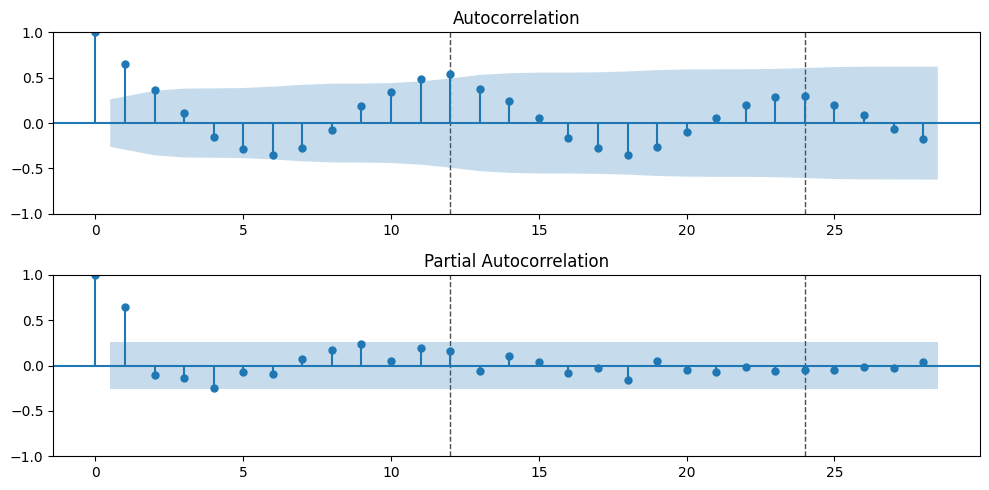

In [109]:
plot_acf_pacf(monthly_cases, annotate_seas=True, m=12, nlags=28);

p , d , q
1 , 1 , 0

P , D , Q
1 , 1 , 0

### 2. Train/Test Split and Manual SARIMA

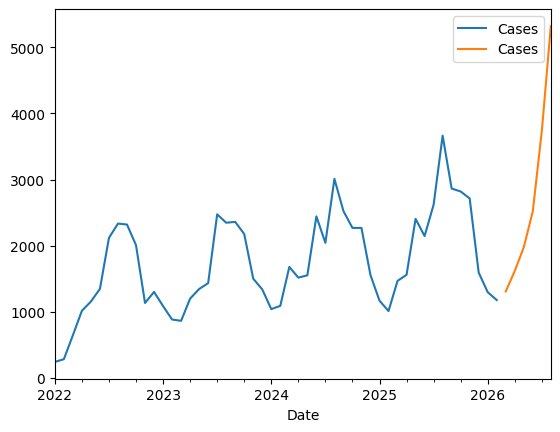

In [110]:
# tts
train, test = train_test_split(monthly_cases, test_size=6)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [111]:
# Orders for non seasonal components
p = 2  # nonseasonal AR
d = 1  # nonseasonal differencing
q = 0  # nonseasonal MA
# Orders for seasonal components
P = 1  # Seasonal AR
D = 1  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

In [112]:
manual_sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 623.656
- MSE = 797,010.897
- RMSE = 892.755
- R^2 = 0.588
- MAPE = 18.30%


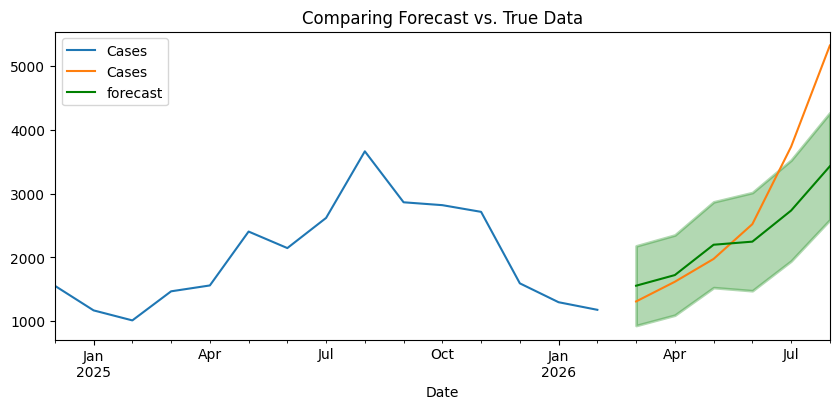

In [113]:
# Obtain summary of forecast as dataframe
manual_forecast_df = manual_sarima.get_forecast(len(test)).summary_frame()
# Plot the forecast with true values
plot_forecast(train, test, manual_forecast_df, n_train_lags=15)
# Obtain metrics
regression_metrics_ts(test, manual_forecast_df["mean"])

In [114]:
manual_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Cases   No. Observations:                   50
Model:             ARIMA(2, 1, 0)x(1, 1, [1], 12)   Log Likelihood                -267.952
Date:                            Sun, 13 Sep 2026   AIC                            545.904
Time:                                    10:29:10   BIC                            553.958
Sample:                                01-01-2022   HQIC                           548.743
                                     - 02-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8554      0.145     -5.886      0.000      -1.140      -0.571
ar.L2         -0.4951      0.150     -3.304      0.001      -0.789      -0.201
ar.S.L12       0.3158      0.381      0.829      0.407      -0.431       1.062
ma.S.L12      -0.9904      0.361     -2.744      0.006      -1.698      -0.283
sigma2      8.477e+04   4.42e-06   1.92e+10      0.000    8.48e+04    8.48e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.87
Prob(Q):                              0.96   Prob(JB):                         0.39
Heteroskedasticity (H):               1.93   Skew:                             0.52
Prob(H) (two-sided):                  0.27   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.93e+26. Standard errors may be unstable.
"""

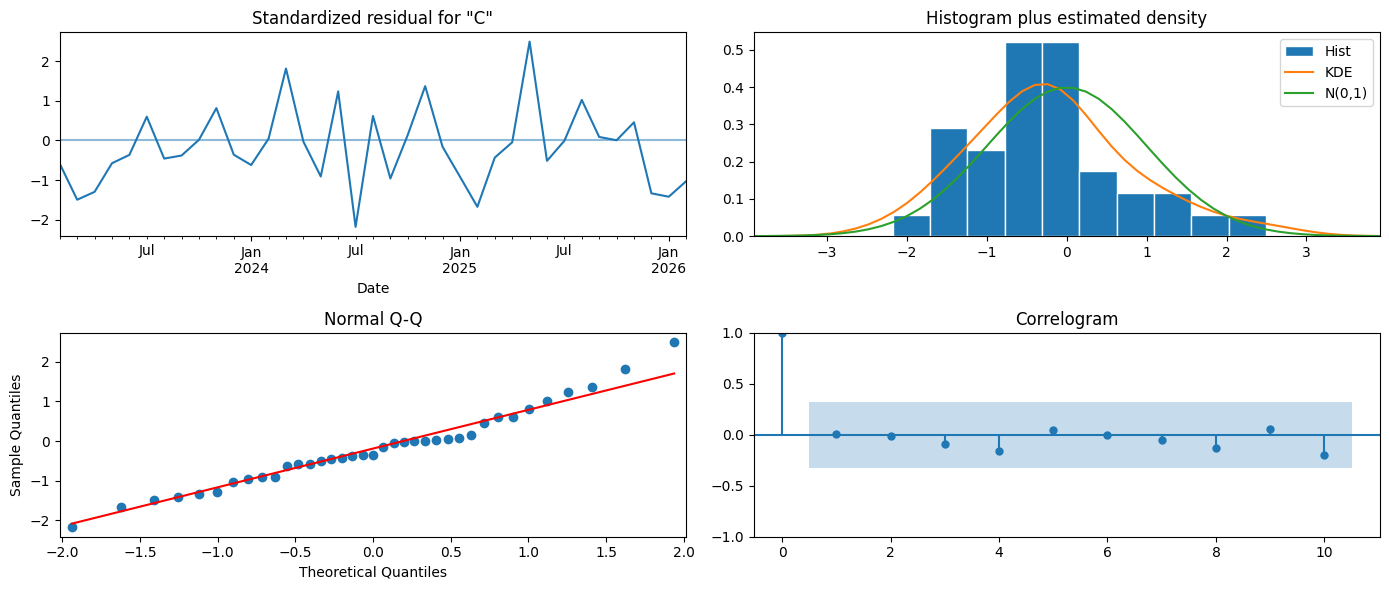

In [115]:
# Obtain diagnostic plots
fig = manual_sarima.plot_diagnostics()
fig.set_size_inches(14,6)
fig.tight_layout()

### 3. Tune wuth `auto_arima`

In [116]:
auto_model = pm.auto_arima(
    train,

    # Non-seasonal parameters
    start_p=0,
    max_p=3,
    d=d,
    start_q=0,
    max_q=3,

    # Seasonal parameters
    seasonal=True,
    m=12,
    start_P=0,
    max_P=2,
    D=D,
    start_Q=0,
    max_Q=2,

    # Model selection
    information_criterion="aic",
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_model.summary())
print("Best model:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=567.509, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=552.093, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.34 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=553.731, Time=0.08 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=554.079, Time=0.40 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=554.081, Time=1.00 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=552.124, Time=2.30 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.04 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=564.760, Time=0.19 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=544.391, Time=1.54 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=546.352, Time=0.18 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=545.929, Time=1.58 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=1.73 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=544.009, Time=0.42 sec
 ARIMA(2,1,0)(0,1,2)[12]             : AIC=54

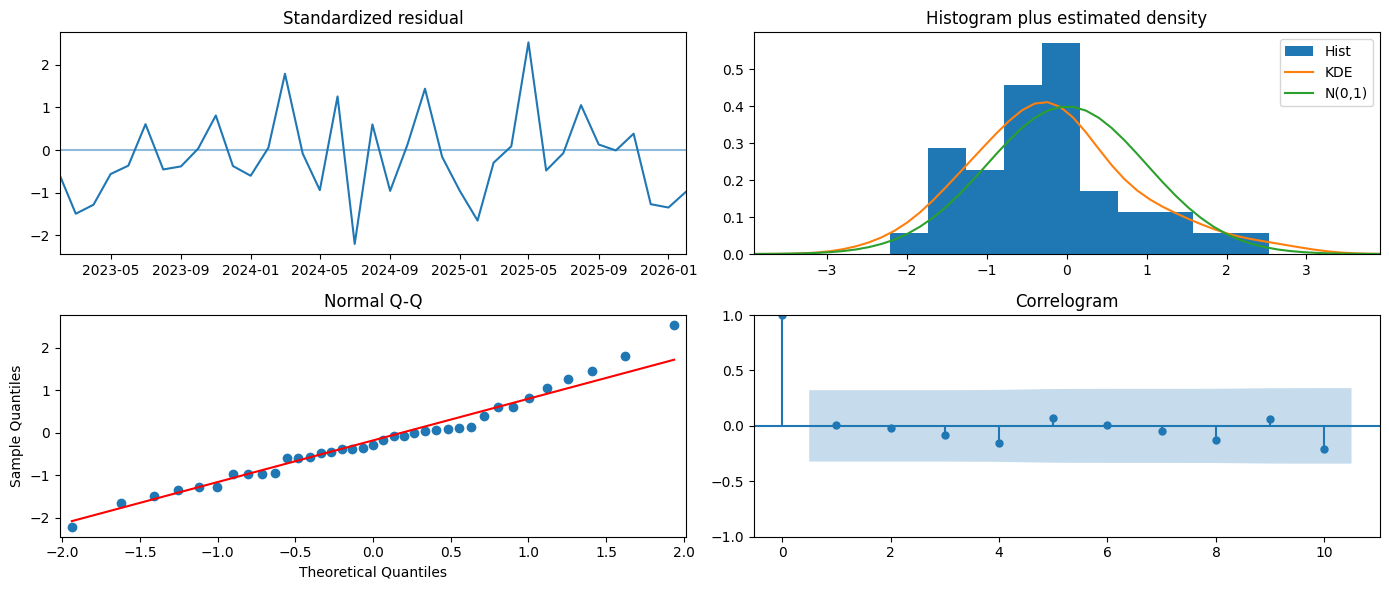

In [117]:
fig = auto_model.plot_diagnostics()
fig.set_size_inches(14, 6)

fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 626.569
- MSE = 806,835.227
- RMSE = 898.240
- R^2 = 0.582
- MAPE = 18.48%


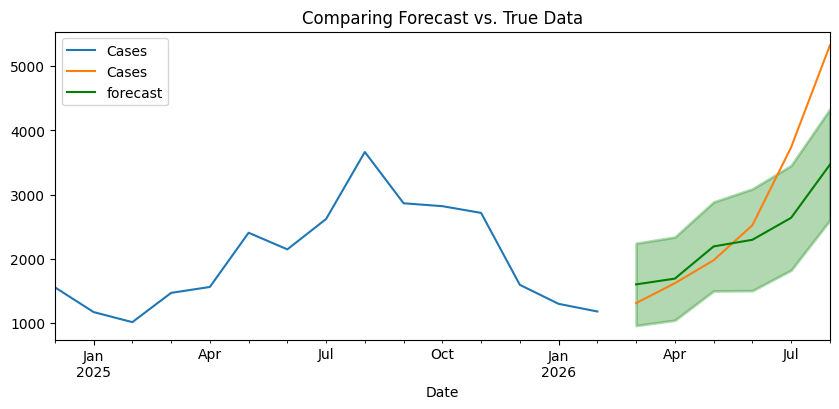

In [118]:
# Obtain forecast and confidence intervals
auto_forecast, auto_conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True)

# Create a DataFrame from the forecast results
auto_forecast_df = pd.DataFrame({
    'mean': auto_forecast,
    'mean_ci_lower': auto_conf_int[:, 0],
    'mean_ci_upper': auto_conf_int[:, 1]
}, index=test.index)

# Plot the forecast with true values
plot_forecast(train, test, auto_forecast_df, n_train_lags=15)
# Obtain metrics
regression_metrics_ts(test, auto_forecast_df["mean"])

### 4. Select the Final Model and Forecast the Future

In [122]:

final_p = 2
final_q = 0
final_d = 1
final_P = 1
final_Q = 1
final_D = 1

final_model = tsa.ARIMA(
    monthly_cases,
    order=(final_p, final_d, final_q),
    seasonal_order=(final_P, final_D, final_Q, 12)).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  start_params = self.start_params


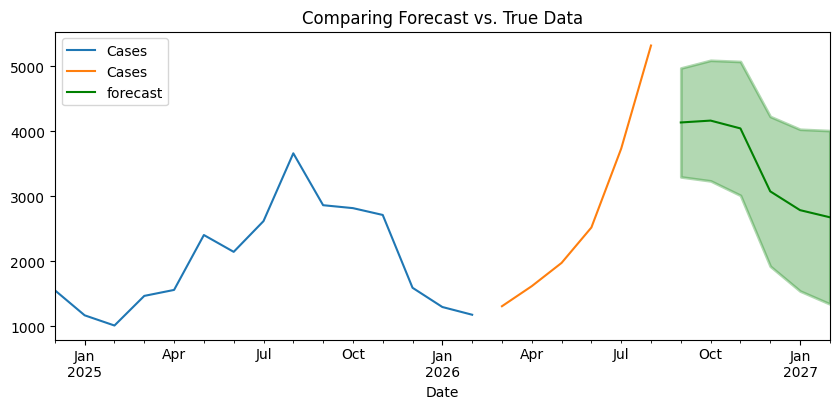

In [127]:
final =final_model.get_forecast(6).summary_frame()

plot_forecast(train, test, final, n_train_lags=15);

## Final Evaluation

In [130]:
# Define the beginning and final forecast values
starting_value = final["mean"].iloc[0]
final_value = final["mean"].iloc[-1]

# Calculate the net change
delta = final_value - starting_value

# Calculate the percentage change
percent_change = (delta / starting_value) * 100

print(f"Beginning forecast: {starting_value:,.0f} cases")
print(f"Final forecast: {final_value:,.0f} cases")
print(f"Net change in Cases: {delta:+,.0f} cases")
print(f"Percentage change: {percent_change:+.2f}%")

Beginning forecast: 4,138 cases
Final forecast: 2,678 cases
Net change in Cases: -1,459 cases
Percentage change: -35.27%
